### Get gene list from composite scoring results
### Julian Moran
### 2026-09-02

In [1]:
import boto3
import glob
import logging
import math
import os
import requests
import s3fs
import time

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from dotenv import load_dotenv
from pathlib import Path

# Env
load_dotenv("../.env", override=True)
REPO_ROOT = os.environ["INSTALL_PATH"]
MINIO_KEY = os.environ["MINIO_KEY"]
MINIO_SECRET = os.environ["MINIO_SECRET"]

# Logging
logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s:%(name)s:%(message)s"
)
logger = logging.getLogger(__name__)

In [35]:
# ============================================================
#       Args
# ============================================================

# Notebook variables
COMP_THRESHOLD = 0.825

# File intake
BUCKET = "iei-project"
PREFIX_GOLD = "03_gold/defense_finder/"
PREFIX_SILVER = "02_silver/defense_finder/"
FILE_COMPOSITE = "composite_score.parquet/part-00000-ac5574c4-cf3c-48a9-98b6-077d4db394f9-c000.snappy.parquet"
FILE_FINAL_OUTPUT = "final_output_spark.parquet/part-00000-bb778272-db05-479f-a79a-2d18e89fe363-c000.snappy.parquet"

FILE_IMMPORT = f"{REPO_ROOT}/data_sync/ImmPort_all_gene_lists.gmt"

# Dirs
OUT_DIR_PLOT = f"{REPO_ROOT}/vis/plots"

# Check live objects in MinIO silver
client = boto3.client(
    "s3",
    endpoint_url="http://eagle.tcag.ca:9000",
    aws_access_key_id=MINIO_SECRET,
    aws_secret_access_key=MINIO_KEY,
)
response = client.list_objects_v2(
    Bucket=BUCKET,
    Prefix=PREFIX_GOLD
)
live_objects = [
    obj["Key"]
    for obj in response.get("Contents", [])
]
live_objects

['03_gold/defense_finder/composite_score.parquet/_SUCCESS',
 '03_gold/defense_finder/composite_score.parquet/part-00000-ac5574c4-cf3c-48a9-98b6-077d4db394f9-c000.snappy.parquet',
 '03_gold/defense_finder/defense_human_domain_annotated.parquet',
 '03_gold/defense_finder/final_output_spark.parquet/_SUCCESS',
 '03_gold/defense_finder/final_output_spark.parquet/part-00000-bb778272-db05-479f-a79a-2d18e89fe363-c000.snappy.parquet',
 '03_gold/defense_finder/griid_gene_subset.parquet',
 '03_gold/defense_finder/human_bacteria_structural_analogs_enriched.parquet',
 '03_gold/defense_finder/human_bacteria_structural_analogs_with_scores.parquet/_SUCCESS',
 '03_gold/defense_finder/human_bacteria_structural_analogs_with_scores.parquet/part-00000-275fe83c-840b-476e-bf63-c47165847863-c000.snappy.parquet']

In [31]:
# ============================================================
#       In
# ============================================================

df_final_output = pl.read_parquet(
    f"s3://{BUCKET}/{PREFIX_GOLD}{FILE_FINAL_OUTPUT}",
    storage_options={
        "aws_endpoint_url": "http://eagle.tcag.ca:9000",
        "aws_access_key_id": MINIO_SECRET,
        "aws_secret_access_key": MINIO_KEY,
    }
)

df_comp_score = pl.read_parquet(
    f"s3://{BUCKET}/{PREFIX_GOLD}{FILE_COMPOSITE}",
    storage_options={
        "aws_endpoint_url": "http://eagle.tcag.ca:9000",
        "aws_access_key_id": MINIO_SECRET,
        "aws_secret_access_key": MINIO_KEY,
    }
)

data_immport = {}
with Path(FILE_IMMPORT).open() as f:
    for line in f:
        fields = line.rstrip("\n").split("\t")
        data_immport[fields[0]] = fields[2:]

df_comp_score

defense_uniprot_ac,human_entryId,composite_score,foldseek_evalue,pymol_rmsd,tm_score_human,tm_score_bacteria,plddt_human,plddt_bacteria
str,str,f64,f64,f32,f32,f32,f32,f32
"""A0A5C5QGP9""","""A0A024R9P6""",0.2646,0.000087,null,null,null,null,83.480003
"""A0A2R3IRC4""","""A0A0D9SF92""",0.8315,1.2070e-7,0.93,0.8169,0.1028,83.199997,77.449997
"""A0A4D8PF33""","""A0A140VK70""",0.2883,0.003094,15.01,0.2908,0.1539,80.290001,83.050003
"""A0A7S9D461""","""A0A140VK70""",0.8986,5.6920e-19,2.18,0.535,0.7678,80.290001,89.629997
"""A0A2K9LJD6""","""A0A1B0GVC6""",0.2795,0.007862,10.88,0.2428,0.29,67.610001,91.379997
…,…,…,…,…,…,…,…,…
"""A0A1D7XM13""","""Q9H4E3""",0.6409,0.000001,4.93,0.6556,0.327,84.879997,82.360001
"""A0A7D6CQE3""","""Q9H4E3""",0.5814,0.000001,5.77,0.6733,0.3337,84.879997,75.230003
"""A0A5P3ALB7""","""Q9H4E3""",0.8713,1.2930e-15,2.68,0.739,0.4786,84.879997,89.019997


In [32]:
col = "Gene Names (primary)"
n = df_final_output.height
non_null = df_final_output[col].is_not_null().sum()
p_w_gene_name = round(non_null / n, 2)

logger.info(f"Pipeline output with annotated gene names {p_w_gene_name}")
logger.info(f"Missing {round(1 - p_w_gene_name, 2)} likely due to accessions being only in UniParc")

df_final_output

INFO:__main__:Pipeline output with annotated gene names 0.67
INFO:__main__:Missing 0.33 likely due to accessions being only in UniParc


defense_uniprot_ac,cluster_repId,defense_taxId,human_entryId,foldseek_evalue,Entry,Reviewed,Entry Name,Protein names,Gene Names,Organism,Length,Gene Names (ordered locus),Gene Names (ORF),Gene Names (primary),Gene Names (synonym),Proteomes,Gene Ontology (biological process),Gene Ontology (cellular component),Gene Ontology (molecular function),Gene Ontology (GO),Gene Ontology IDs,FunFam,CDD,Gene3D,InterPro,PANTHER,Pfam,PROSITE,SMART,RefSeq,human_domains,defense_type,defense_subtype
str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""D5H7G1""","""A0A2P4VLT1""","""761659""","""A0A024QZ20""",4.6620e-13,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""Gao_TerY""","""Gao_TerY"""
"""A0A0S2KJ89""","""A0A858BYG8""","""76123""","""A0A024R746""",0.000001,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""CBASS""","""CBASS_II"""
"""A0A1L3LSP8""","""A0A858BYG8""","""194963""","""A0A024R746""",0.000001,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""CBASS""","""CBASS_I"""
"""A0A2G9LHY5""","""A0A858BYG8""","""573""","""A0A024R746""",0.000001,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""CBASS""","""CBASS_II"""
"""A0A2K9Z6V0""","""A0A858BYG8""","""384""","""A0A024R746""",0.000001,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""CBASS""","""CBASS_I"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""A0A5P8W2P0""","""A0A3S9MKD2""","""2653204""","""X5D2R5""",0.0005861,"""X5D2R5""","""unreviewed""","""X5D2R5_HUMAN""","""Iron-sulfur cluster transfer p…","""NUBPL""","""Homo sapiens (Human)""","""319""",null,null,"""NUBPL""",null,null,"""iron-sulfur cluster assembly […","""mitochondrial matrix [GO:00057…","""4 iron, 4 sulfur cluster bindi…","""mitochondrial matrix [GO:00057…","""GO:0005524; GO:0005739; GO:000…","""3.40.50.300:FF:000709;""","""cd02037;""","""3.40.50.300;""","""IPR000808;IPR019591;IPR044304;…","""PTHR42961;PTHR42961:SF2;""","""PF10609;""","""PS01215;""",null,"""NP_079428.2;""",null,"""PsyrTA""","""PsyrTA"""
"""A7HKC7""","""A0A3S9MKD2""","""381764""","""X5D2R5""",0.0005861,"""X5D2R5""","""unreviewed""","""X5D2R5_HUMAN""","""Iron-sulfur cluster transfer p…","""NUBPL""","""Homo sapiens (Human)""","""319""",null,null,"""NUBPL""",null,null,"""iron-sulfur cluster assembly […","""mitochondrial matrix [GO:00057…","""4 iron, 4 sulfur cluster bindi…","""mitochondrial matrix [GO:00057…","""GO:0005524; GO:0005739; GO:000…","""3.40.50.300:FF:000709;""","""cd02037;""","""3.40.50.300;""","""IPR000808;IPR019591;IPR044304;…","""PTHR42961;PTHR42961:SF2;""","""PF10609;""","""PS01215;""",null,"""NP_079428.2;""",null,"""PsyrTA""","""PsyrTA"""
"""E4TBU2""","""A0A3S9MKD2""","""693978""","""X5D2R5""",0.0005861,"""X5D2R5""","""unreviewed""","""X5D2R5_HUMAN""","""Iron-sulfur cluster transfer p…","""NUBPL""","""Homo sapiens (Human)""","""319""",null,null,"""NUBPL""",null,null,"""iron-sulfur cluster assembly […","""mitochondrial matrix [GO:00057…","""4 iron, 4 sulfur cluster bindi…","""mitochondrial matrix [GO:00057…","""GO:0005524; GO:0005739; GO:000…","""3.40.50.300:FF:000709;""","""cd02037;""","""3.40.50.300;""","""IPR000808;IPR019591;IPR044304;…","""PTHR42961;PTHR42961:SF2;""","""PF10609;""","""PS01215;""",null,"""NP_079428.2;""",null,"""ShosTA""","""ShosTA"""


In [33]:
logger.info(f"N ImmPort immune system pathways: {len(data_immport)}")
data_immport

INFO:__main__:N ImmPort immune system pathways: 153


{'Activation of innate immune response': ['AIM2',
  'ALPK1',
  'AP3B1',
  'BCL10',
  'BECN1',
  'BTK',
  'CASP1',
  'CASP6',
  'CD14',
  'CD274',
  'CD300LF',
  'CGAS',
  'CHUK',
  'CLEC4E',
  'CLEC6A',
  'CLEC7A',
  'CLPB',
  'COLEC10',
  'COLEC11',
  'COLEC12',
  'CREBBP',
  'CTSS',
  'CYLD',
  'DHX58',
  'ECSIT',
  'EP300',
  'EPG5',
  'FCN1',
  'FCN2',
  'FCN3',
  'FFAR2',
  'FOSL1',
  'FYN',
  'GBP2',
  'GBP5',
  'HAVCR2',
  'HCK',
  'HEXIM1',
  'HMGB1',
  'HSP90AA1',
  'HSPD1',
  'IFI16',
  'IFIH1',
  'IKBKB',
  'INAVA',
  'IPO5',
  'IRAK1',
  'IRAK2',
  'IRAK3',
  'IRAK4',
  'IRF3',
  'IRF7',
  'IRGM',
  'ITCH',
  'KIR2DS2',
  'KLRC1',
  'KLRC2',
  'KLRC3',
  'KLRC4',
  'KLRC4-KLRK1',
  'KLRD1',
  'KLRK1',
  'LACC1',
  'LBP',
  'LILRA2',
  'LRRC19',
  'LSM14A',
  'LY96',
  'LYN',
  'MAP2K6',
  'MAP3K7',
  'MAPKAPK2',
  'MAPKAPK3',
  'MATR3',
  'MAVS',
  'MBL2',
  'MEFV',
  'MNDA',
  'MYD88',
  'NAGLU',
  'NAIP',
  'NFKBIA',
  'NFKBIZ',
  'NLRC4',
  'NLRP1',
  'NLRP10',
  'NLRP3'

In [66]:
# ============================================================
#       Annotate, filter df_comp_score
# ============================================================

df_comp_score_ann = df_comp_score.join(
    df_final_output.select([
        "defense_uniprot_ac",
        "human_entryId",
        "Gene Names (primary)",
        "defense_type",
        "defense_subtype",
    ]),
    on=["defense_uniprot_ac", "human_entryId"],
    how="left",
)

# Immport annotation (`;`-delimited for compound annotations)
gene_to_immport = {}
for pathway, genes in data_immport.items():
    for gene in genes:
        gene_to_immport.setdefault(gene, []).append(pathway)
gene_to_immport = {gene: "; ".join(pathways) for gene, pathways in gene_to_immport.items()}

# Annotate
df_comp_score_ann = df_comp_score_ann.with_columns(
    pl.col("Gene Names (primary)")
    .replace_strict(gene_to_immport, default=None)
    .alias("ImmPort")
)

# Filter
df_comp_score_bckg = df_comp_score_ann.filter(
    (pl.col("composite_score") < COMP_THRESHOLD)
    & pl.col("Gene Names (primary)").is_not_null()
)
n_immport_bckg = df_comp_score_bckg["ImmPort"].is_not_null().sum()
p_immport_bckg = round((n_immport_bckg / len(df_comp_score_bckg)), 3)
logger.info(f"Background: n protein pairs with ImmPort pathway annotation: {n_immport_bckg}")
logger.info(f"Background: p protein pairs with ImmPort pathway annotation: {p_immport_bckg}")

df_comp_score_filt = df_comp_score_ann.filter(
    (pl.col("composite_score") >= COMP_THRESHOLD)
    & pl.col("Gene Names (primary)").is_not_null()
)
n_immport_filt = df_comp_score_filt["ImmPort"].is_not_null().sum()
p_immport_filt = round((n_immport_filt / len(df_comp_score_filt)), 3)
logger.info(f">={COMP_THRESHOLD} set: n protein pairs with ImmPort pathway annotation: {n_immport_filt}")
logger.info(f">={COMP_THRESHOLD} set: p protein pairs with ImmPort pathway annotation: {p_immport_filt}")
df_comp_score_filt

INFO:__main__:Background: n protein pairs with ImmPort pathway annotation: 134617
INFO:__main__:Background: p protein pairs with ImmPort pathway annotation: 0.202
INFO:__main__:>=0.825 set: n protein pairs with ImmPort pathway annotation: 14975
INFO:__main__:>=0.825 set: p protein pairs with ImmPort pathway annotation: 0.237


defense_uniprot_ac,human_entryId,composite_score,foldseek_evalue,pymol_rmsd,tm_score_human,tm_score_bacteria,plddt_human,plddt_bacteria,Gene Names (primary),defense_type,defense_subtype,ImmPort
str,str,f64,f64,f32,f32,f32,f32,f32,str,str,str,str
"""A0A2R3IRC4""","""A0A0D9SF92""",0.8315,1.2070e-7,0.93,0.8169,0.1028,83.199997,77.449997,"""CHD2""","""Zorya""","""Zorya_TypeI""",null
"""A0A380U8L2""","""A0A6Q8PGT6""",0.8317,2.2820e-33,3.2,0.5354,0.395,77.739998,77.080002,"""IGHMBP2""","""Mokosh""","""Mokosh_Type_I_C""",null
"""Q9XBB4""","""A0A141AXF6""",0.8427,1.2500e-10,1.83,0.3295,0.409,75.0,89.32,"""FGFR2""","""Stk2""","""Stk2""",null
"""A0A0F7KBN7""","""C9JUP7""",0.8252,9.6680e-15,3.36,0.3037,0.7224,81.75,90.230003,"""VCP""","""CBASS""","""CBASS_III""","""Neutrophil degranulation"""
"""Q96Z85""","""Q7Z3Z4""",0.85,2.3030e-33,3.31,0.4271,0.7542,85.230003,84.760002,"""PIWIL4""","""pAgo""","""pAgo_LongB""",null
…,…,…,…,…,…,…,…,…,…,…,…,…
"""A0A857GPF0""","""K0J110""",0.8611,1.9270e-22,2.55,0.4594,0.4796,69.309998,88.459999,"""mcdrh""","""PsyrTA""","""PsyrTA""",null
"""A0A6L9JU86""","""Q6PL18""",0.8478,6.8610e-17,2.3,0.1929,0.6575,61.540001,81.419998,"""ATAD2""","""Gao_Iet""","""Gao_Iet""",null
"""A0A250IWT1""","""Q9BVC4""",0.871,2.0190e-14,1.83,0.7803,0.3497,91.639999,53.220001,"""MLST8""","""Septu""","""Septu""","""Costimulation by the CD28 fami…"


### Gene list

Additional filtering criteria:
1. Has UniProtKB ID (p = 0.66)
2. Has composite score >= 0.825

In [49]:
# ============================================================
#       Get gene list
# ============================================================

# Quantify
df_comp_score_bckg_genes = df_comp_score_bckg.unique(subset=["Gene Names (primary)"], keep="first")
n_immport_bckg_gene_list = df_comp_score_bckg_genes["ImmPort"].is_not_null().sum()
p_immport_bckg_gene_list = round((n_immport_bckg_gene_list / len(df_comp_score_bckg_genes)), 3)
logger.info(f"Background gene list: n gene rows with ImmPort annotation: {n_immport_bckg_gene_list}")
logger.info(f"Background gene list: p genes with ImmPort pathway annotation: {p_immport_bckg_gene_list}")

df_comp_genes = df_comp_score_filt.unique(subset=["Gene Names (primary)"], keep="first")
n_immport_gene_list = df_comp_genes["ImmPort"].is_not_null().sum()
p_immport_gene_list = round((n_immport_gene_list / len(df_comp_genes)), 3)

logger.info(f">={COMP_THRESHOLD} gene list: n gene rows with ImmPort annotation: {n_immport_gene_list}")
logger.info(f">={COMP_THRESHOLD} gene list: p genes with ImmPort pathway annotation: {p_immport_gene_list}")

df_comp_genes

INFO:__main__:Background gene list: n gene rows with ImmPort annotation: 640
INFO:__main__:Background gene list: p genes with ImmPort pathway annotation: 0.175


INFO:__main__:>=0.825 gene list: n gene rows with ImmPort annotation: 178
INFO:__main__:>=0.825 gene list: p genes with ImmPort pathway annotation: 0.177


defense_uniprot_ac,human_entryId,composite_score,foldseek_evalue,pymol_rmsd,tm_score_human,tm_score_bacteria,plddt_human,plddt_bacteria,Gene Names (primary),defense_type,defense_subtype,ImmPort
str,str,f64,f64,f32,f32,f32,f32,f32,str,str,str,str
"""A0A250IWT1""","""P63244""",0.903,7.6320e-18,1.2,0.8804,0.3784,92.440002,53.220001,"""RACK1""","""Septu""","""Septu""",null
"""A0A0F6HEA8""","""G3V576""",0.8511,2.5730e-9,0.18,0.259,0.2793,72.370003,92.269997,"""HNRNPC""","""Cas""","""CAS_Class1-Subtype-I-B""",null
"""A0A250IWT1""","""Q96J01""",0.8738,3.6480e-15,1.84,0.7837,0.3772,90.199997,53.220001,"""THOC3""","""Septu""","""Septu""",null
"""R9RJ65""","""Q8IWB3""",0.8759,7.8370e-14,0.97,0.5558,0.2094,72.059998,80.139999,"""PCTK3""","""PD-T4-6""","""PD-T4-6""",null
"""A0A250IWT1""","""G3V201""",0.8828,5.7210e-19,1.71,0.7746,0.3687,87.220001,53.220001,"""WDR90""","""Septu""","""Septu""",null
…,…,…,…,…,…,…,…,…,…,…,…,…
"""S7TRZ0""","""G3V546""",0.8549,1.3750e-8,0.34,0.4506,0.2941,77.470001,93.900002,"""RBM23""","""Cas""","""CAS_Class1-Subtype-I-B""",null
"""C1DRC1""","""W0S0D3""",0.861,3.6660e-10,1.93,0.6991,0.4028,93.900002,80.519997,"""Pe1Fe13""","""PD-T4-6""","""PD-T4-6""",null
"""A0A660GDJ5""","""C9IY94""",0.8519,1.2730e-9,1.23,0.5701,0.2682,75.089996,88.550003,"""SEPTIN2""","""Eleos""","""Eleos""",null


In [67]:
df_comp_score_bckg_genes

defense_uniprot_ac,human_entryId,composite_score,foldseek_evalue,pymol_rmsd,tm_score_human,tm_score_bacteria,plddt_human,plddt_bacteria,Gene Names (primary),defense_type,defense_subtype,ImmPort
str,str,f64,f64,f32,f32,f32,f32,f32,str,str,str,str
"""A0A3W0CUD2""","""Q13907""",0.5148,0.000002,6.81,0.3336,0.2181,97.110001,91.18,"""IDI1""","""ShosTA""","""ShosTA""",null
"""G0VP17""","""Q05CX8""",0.4272,0.03988,5.3,0.2294,0.317,71.25,94.050003,"""TDG""","""RM""","""RM_Type_II""",null
"""A0A859QGQ8""","""Q8WVL7""",0.3614,0.000032,18.23,0.289,0.1357,81.629997,84.75,"""ANKRD49""","""NLR""","""NLR_like_bNACHT01""",null
"""A0A0H4X8M5""","""K7ERH1""",0.6597,0.0001471,2.93,0.226,0.1729,60.779999,89.919998,"""CELF4""","""Cas""","""CAS_Class1-Subtype-III-B""",null
"""A0A212L7M1""","""E9PRH9""",0.4444,7.3050e-9,11.13,0.3911,0.1494,71.339996,87.860001,"""NASP""","""Rst_TIR-NLR""","""Rst_TIR-NLR""",null
…,…,…,…,…,…,…,…,…,…,…,…,…
"""I3TMS8""","""Q6IE37""",0.5405,0.004615,4.0,0.0868,0.264,65.230003,86.480003,"""OVOS1""","""Thoeris""","""Thoeris_I""",null
"""C1DRC1""","""Q6FG25""",0.82,3.6660e-10,2.35,0.4669,0.3921,74.150002,80.519997,"""MAP3K8""","""PD-T4-6""","""PD-T4-6""","""Costimulation by the CD28 fami…"
"""A0A7G5GRL3""","""Q9H0W8""",0.2606,0.04124,9.38,0.3223,0.3693,70.57,83.330002,"""SMG9""","""Eleos""","""Eleos""",null


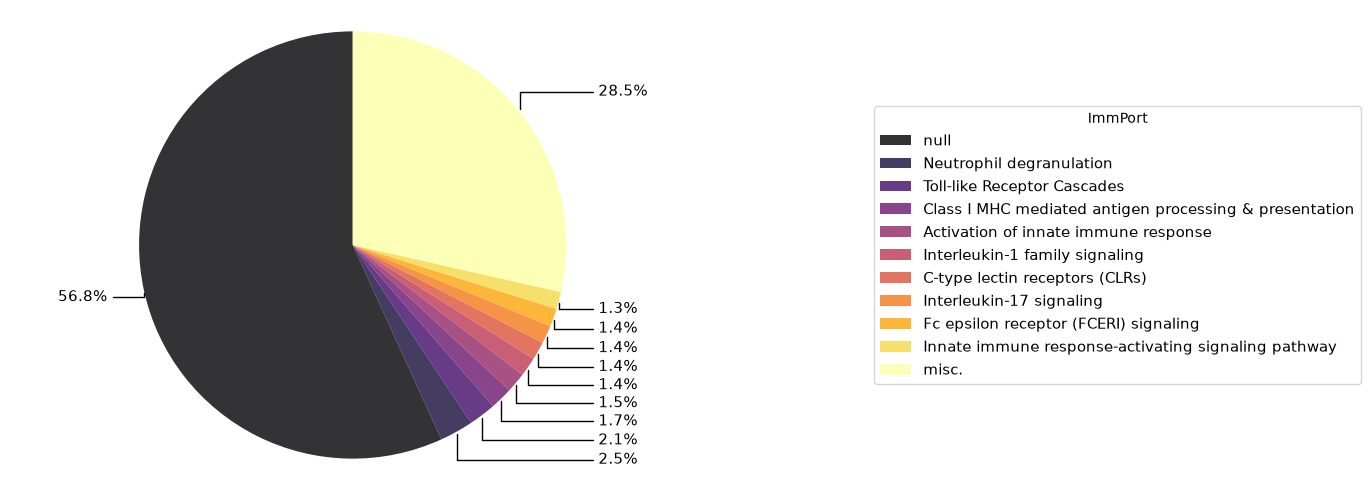

In [82]:
# ============================================================
#       Plot 1: ImmPort [gene list]
# ============================================================

def plot_immport_pie(
    data,
    cpal : str = "Set3",
    alpha: float = 0.8,
    font_size: int = 14,
    n: int = 6,
    col_ann: str = "ImmPort",
    split_compound: bool = False,
    dims: tuple = (6, 10),
    out: str|None = None

):
    # Wrangle; split out compound annotations
    if split_compound:
        counts = (
            data.select(
                pl.col(col_ann).fill_null("null").str.split("; ").alias(col_ann)
            )
            .explode(col_ann)
            .group_by(col_ann)
            .len()
            .sort("len", descending=True)
        )
    else:
        counts = (
            data.select(
                pl.col(col_ann)
                .fill_null("null")
                .str.split("; ")
                .list.first()
                .alias(col_ann)
            )
            .group_by(col_ann)
            .len()
            .sort("len", descending=True)
        )

    # Wrangle: get only top `n` annotations and group remainder under "misc."
    top = counts.head(n)
    labels = top[col_ann].to_list()
    sizes = top["len"].to_list()

    misc_total = counts.slice(n)["len"].sum()
    if misc_total > 0:
        labels.append("misc.")
        sizes.append(misc_total)

    # Colours
    cmap = plt.get_cmap(cpal)
    colors = [cmap(i / max(len(sizes) - 1, 1)) for i in range(len(sizes))]

    # Plot
    fig, ax = plt.subplots(figsize=dims)
    wedges, _ = ax.pie(
        sizes,
        colors=colors,
        startangle=90,
        wedgeprops={"alpha": alpha},
    )

    # Annotate slices with percentages
    total = sum(sizes)
    for wedge, size in zip(wedges, sizes):
        percentage = 100 * size / total
        angle = (wedge.theta1 + wedge.theta2) / 2
        x = np.cos(np.deg2rad(angle))
        y = np.sin(np.deg2rad(angle))
        ax.annotate(
            f"{percentage:.1f}%",
            xy=(x, y),
            xytext=(1.15 * np.sign(x), 1.15 * y),
            ha="left" if x >= 0 else "right",
            va="center",
            fontsize=font_size,
            arrowprops={
                "arrowstyle": "-",
                "connectionstyle": "angle,angleA=0,angleB=90",
            },
        )

    ax.legend(
        wedges,
        labels,
        title=col_ann,
        loc="center left",
        bbox_to_anchor=(1.25, 0.0, 0.5, 1.0),
        fontsize=font_size,
    )
    ax.axis("equal")
    fig.tight_layout()

    if out is not None:
        os.makedirs(os.path.dirname(out), exist_ok=True)
        fig.savefig(f"{out}.svg", bbox_inches="tight")
        fig.savefig(f"{out}.png", dpi=300, bbox_inches="tight")
        plt.show()

plot_immport_pie(
    data=df_comp_genes,
    cpal="inferno",
    alpha=0.8,
    font_size=11,
    n=10,
    col_ann="ImmPort",
    split_compound=True,
    dims=(15, 5),
    out=f"{REPO_ROOT}/vis/plots/pie_plot_immport_compoundAnn"
)

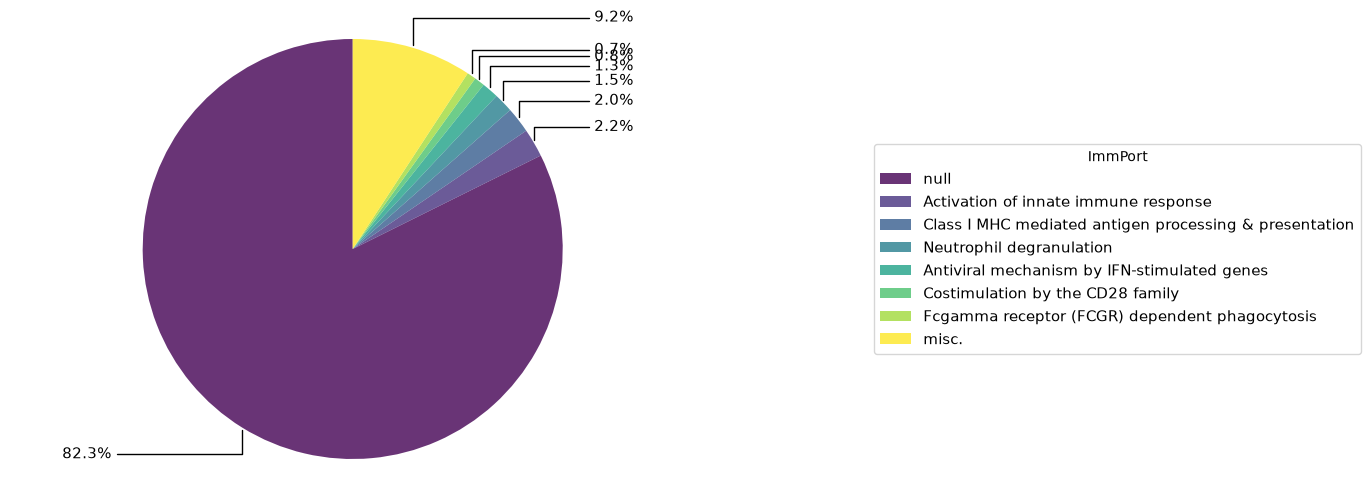

In [85]:
plot_immport_pie(
    data=df_comp_genes,
    cpal="viridis",
    alpha=0.8,
    font_size=11,
    n=7,
    col_ann="ImmPort",
    split_compound=False,
    dims=(15, 5),
    out=f"{REPO_ROOT}/vis/plots/pie_plot_immport"
)

In [59]:
# ============================================================
#       Analysis 2: permutation test
# ============================================================

def permutation_test(
    data: pl.DataFrame,
    col_ann: str,
    n_iter: int,
    sample_size: int
) -> pl.Series:
    data = data.select(col_ann)
    diffs = []
    for _ in range(n_iter):
        shuffled = data.sample(
            fraction=1.0,
            shuffle=True
        )
        sample = shuffled.head(sample_size)
        background = shuffled.tail(len(data) - sample_size)

        sample_prop = sample[col_ann].is_not_null().mean()
        background_prop = background[col_ann].is_not_null().mean()

        diffs.append(sample_prop - background_prop)

    return pl.Series("permutations", diffs)

df_comp_score_immport = pl.concat([df_comp_score_filt, df_comp_score_bckg])

immport_prm_test = permutation_test(
    data=df_comp_score_immport,
    col_ann = "ImmPort",
    n_iter=10000,
    sample_size=len(df_comp_score_filt)
)

immport_prm_test

permutations
f64
0.003807
-0.000804
-0.002052
-0.002832
-0.000266
…
-0.002364
-0.000613
0.000496


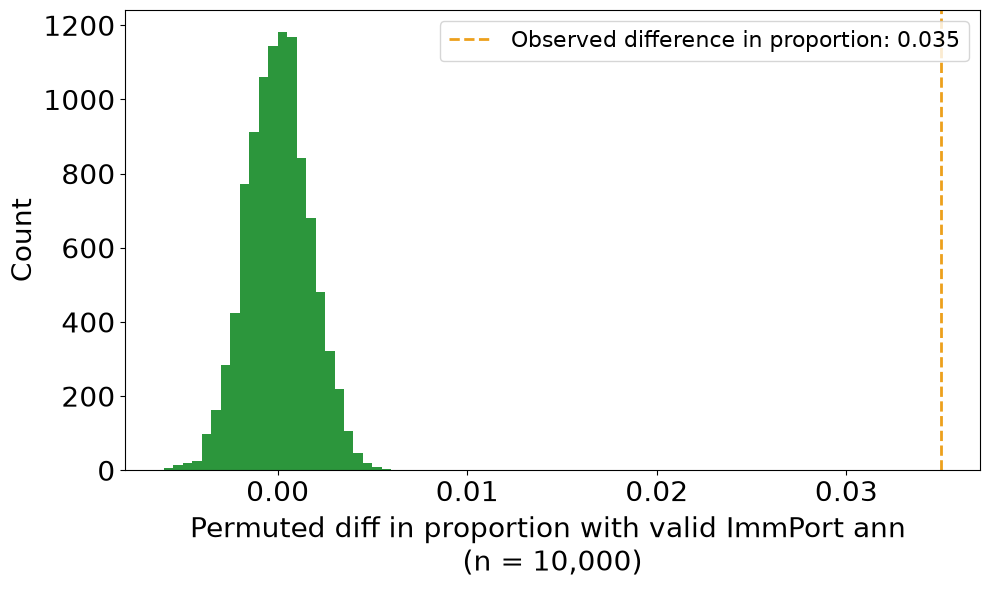

In [68]:
# ============================================================
#       Plot 2: permutation test
# ============================================================

def permutation_hist(
    permutation_diffs: pl.Series,
    observed_diff: float,
    bin_width: float,
    x_label: str = "Permuted difference in observed proportion",
    y_label: str = "Count",
    colour_1: str = "#2C963C",
    colour_2: str = "#EDA01C",
    dims: tuple[int, int] = (10, 6),
    alpha: float = 1.0,
    axis_font_size: int = 20,
    label_font_size: int = 16,
    out: str | None = None,
) -> None:
    bins = np.arange(
        np.floor(min(permutation_diffs) / bin_width) * bin_width,
        np.ceil(max(permutation_diffs) / bin_width) * bin_width + bin_width,
        bin_width,
    )
    plt.figure(figsize=dims)
    plt.hist(
        permutation_diffs.drop_nulls().to_list(),
        bins=bins,
        alpha=alpha,
        color=colour_1,
    )
    plt.axvline(observed_diff, color=colour_2, linestyle="--", linewidth=2, label=f"Observed difference in proportion: {observed_diff}")
    plt.xlabel(x_label, fontsize=axis_font_size)
    plt.ylabel(y_label, fontsize=axis_font_size)
    plt.xticks(fontsize=axis_font_size)
    plt.yticks(fontsize=axis_font_size)
    plt.legend(fontsize=label_font_size)
    plt.tight_layout()

    if out is not None:
        plt.savefig(f"{out}.svg")
        plt.savefig(f"{out}.png", dpi=1080)

    plt.show()
    return None

observed_diff = p_immport_filt - p_immport_bckg
permutation_hist(
    permutation_diffs=immport_prm_test,
    observed_diff=round(observed_diff, 3),
    x_label=f"Permuted diff in proportion with valid ImmPort ann \n(n = {len(immport_prm_test):,})",
    bin_width=0.0005,
    out=f"{REPO_ROOT}/vis/plots/hist_diff_ImmPort_permute"
)

In [ ]:
pl.Config.set_tbl_rows(115)


0